# **Predictive Healthcare System**

# **Dataset Loading and Initial Overview**

In [91]:
import pandas as pd

df = pd.read_csv('/content/heart_disease.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [92]:
print("First 5 rows of the DataFrame:")
df.head()

First 5 rows of the DataFrame:


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [93]:
print("\nDataFrame Info (data types and non-null counts):")
df.info()

print("\nMissing values per column:")
df.isnull().sum()


DataFrame Info (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours          

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [94]:
print("\nDescriptive statistics for numerical columns:")
df.select_dtypes(include=['float64']).describe()


Descriptive statistics for numerical columns:


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


# **Imputation of Missing Values**

In [95]:
numerical_cols_to_impute = [
    'Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
    'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level'
]

print("Imputing missing numerical values with median...")
for col in numerical_cols_to_impute:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Missing values in '{col}' imputed with median: {median_val}")

print("\nMissing values after imputation for specified numerical columns:")
print(df[numerical_cols_to_impute].isnull().sum())

Imputing missing numerical values with median...
Missing values in 'Age' imputed with median: 49.0
Missing values in 'Blood Pressure' imputed with median: 150.0
Missing values in 'Cholesterol Level' imputed with median: 226.0
Missing values in 'BMI' imputed with median: 29.079491590086043
Missing values in 'Sleep Hours' imputed with median: 7.003252334814371
Missing values in 'Triglyceride Level' imputed with median: 250.0
Missing values in 'Fasting Blood Sugar' imputed with median: 120.0
Missing values in 'CRP Level' imputed with median: 7.472164393020417
Missing values in 'Homocysteine Level' imputed with median: 12.409395381646618

Missing values after imputation for specified numerical columns:
Age                    0
Blood Pressure         0
Cholesterol Level      0
BMI                    0
Sleep Hours            0
Triglyceride Level     0
Fasting Blood Sugar    0
CRP Level              0
Homocysteine Level     0
dtype: int64


In [96]:
categorical_cols_to_impute = [
    'Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
    'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
    'Alcohol Consumption', 'Stress Level', 'Sugar Consumption'
]

print("Imputing missing categorical values with mode...")
for col in categorical_cols_to_impute:
    # Using .mode()[0] to handle cases where there might be multiple modes,
    # by selecting the first one.
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"Missing values in '{col}' imputed with mode: {mode_val}")

print("\nMissing values after imputation for specified categorical columns:")
print(df[categorical_cols_to_impute].isnull().sum())

Imputing missing categorical values with mode...
Missing values in 'Gender' imputed with mode: Male
Missing values in 'Exercise Habits' imputed with mode: High
Missing values in 'Smoking' imputed with mode: Yes
Missing values in 'Family Heart Disease' imputed with mode: No
Missing values in 'Diabetes' imputed with mode: No
Missing values in 'High Blood Pressure' imputed with mode: Yes
Missing values in 'Low HDL Cholesterol' imputed with mode: Yes
Missing values in 'High LDL Cholesterol' imputed with mode: No
Missing values in 'Alcohol Consumption' imputed with mode: Medium
Missing values in 'Stress Level' imputed with mode: Medium
Missing values in 'Sugar Consumption' imputed with mode: Low

Missing values after imputation for specified categorical columns:
Gender                  0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     

In [97]:
print("\nVerifying all missing values after imputation:")
print(df.isnull().sum())


Verifying all missing values after imputation:
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64


## **Data Visualization (Numerical and Categorical Features)**

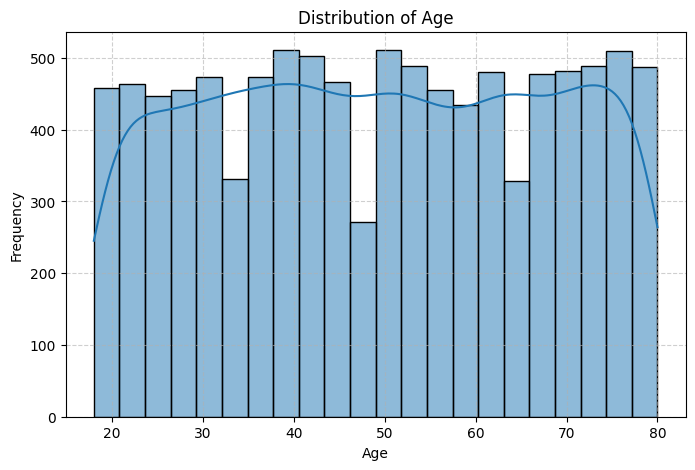

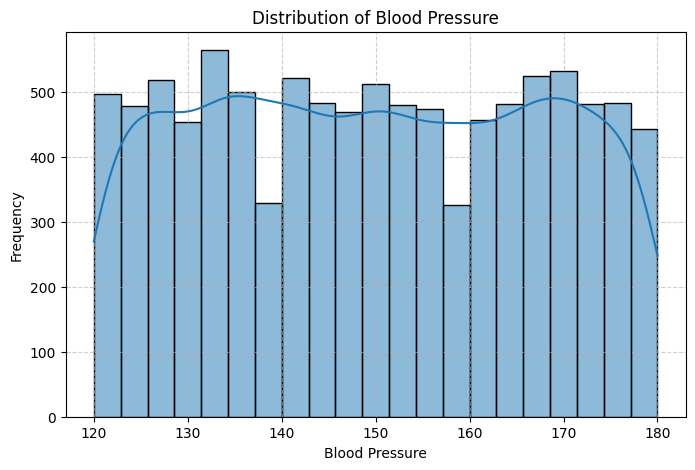

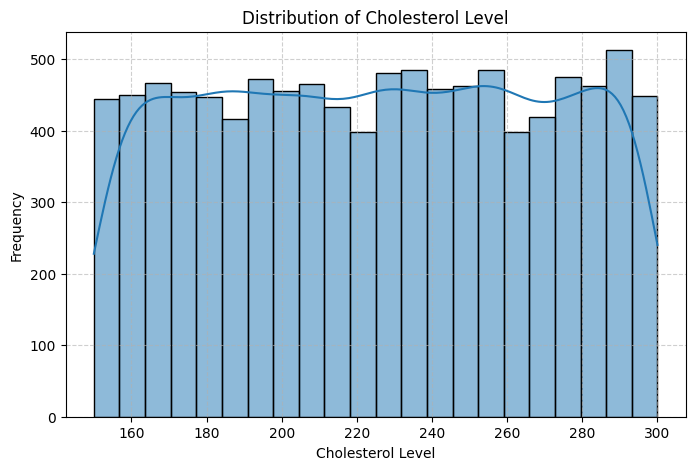

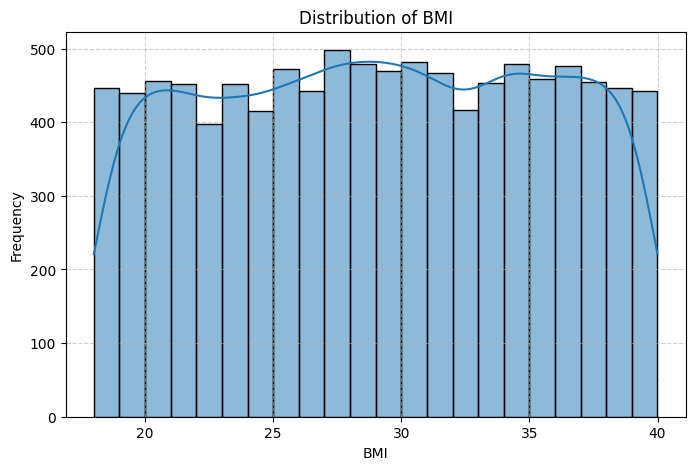

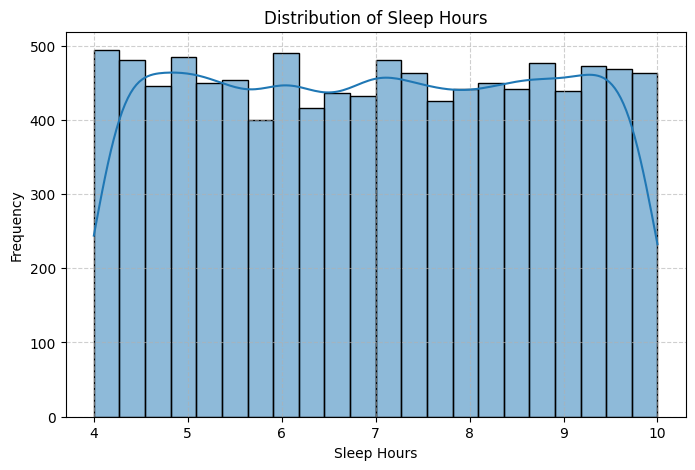

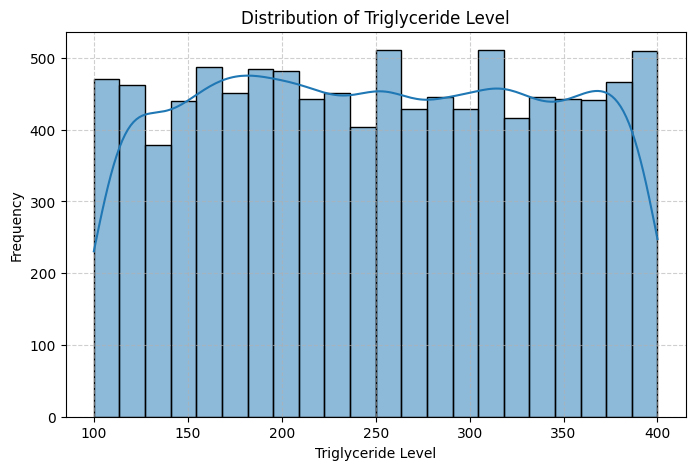

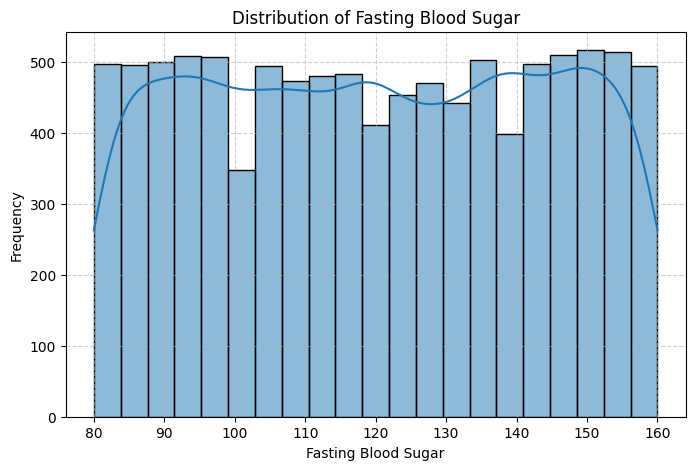

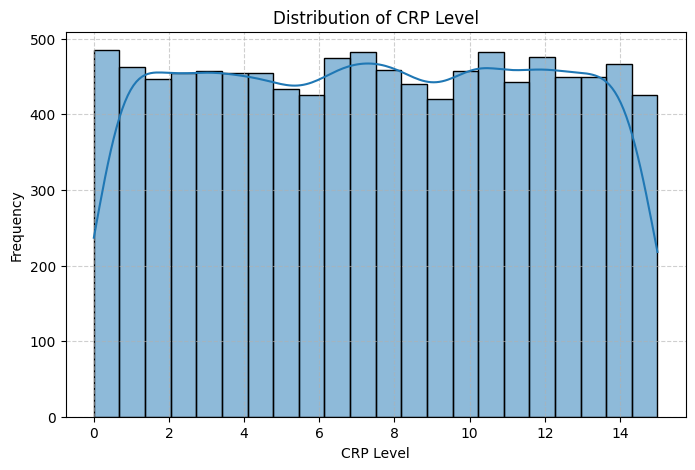

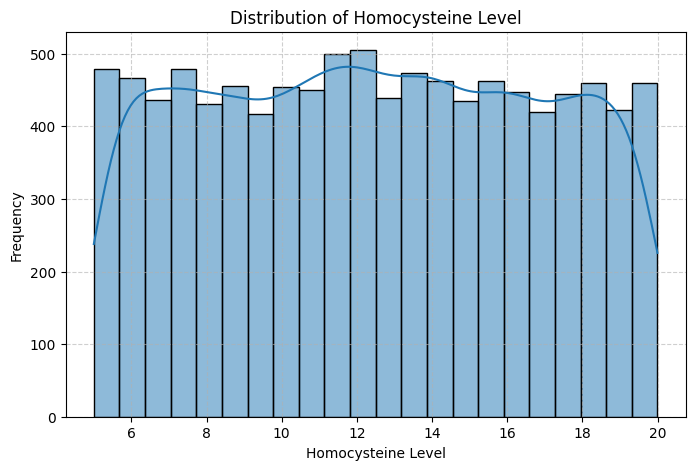

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

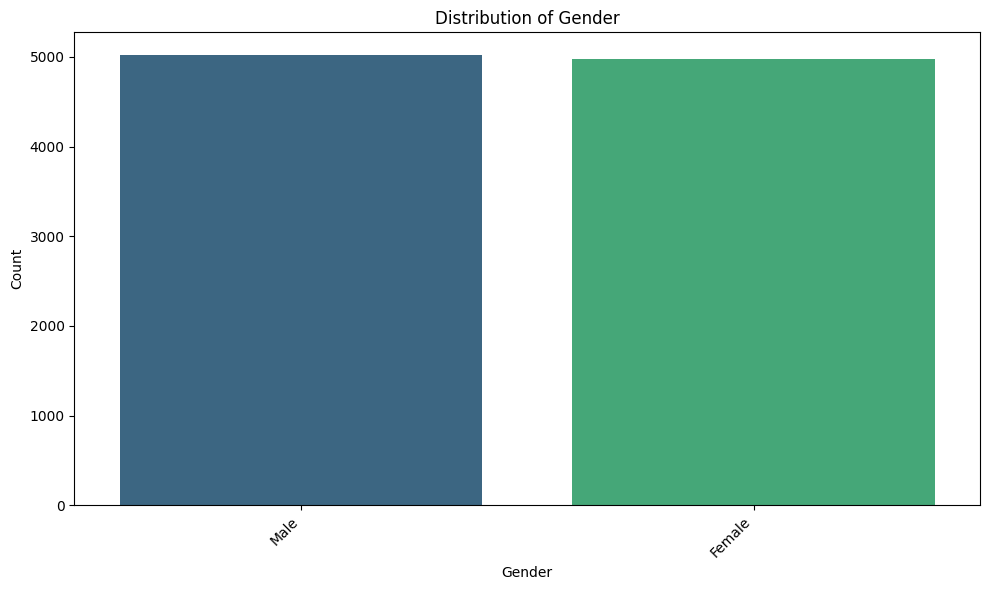

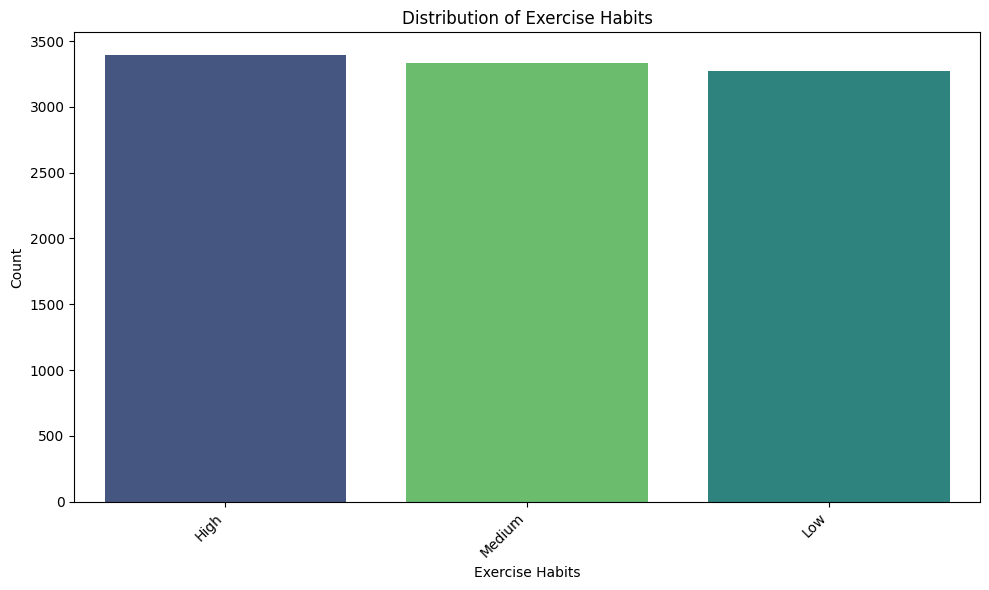

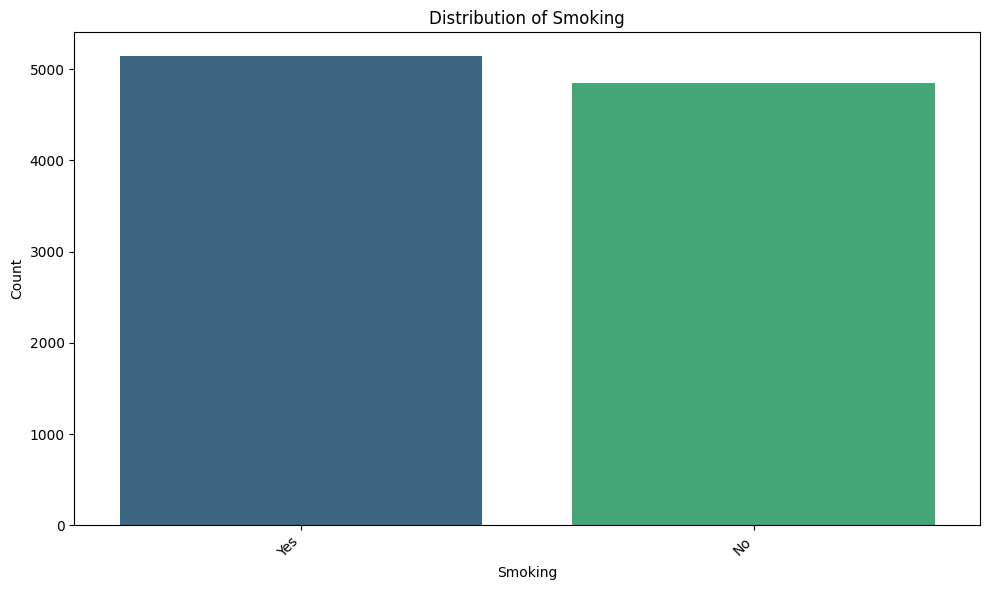

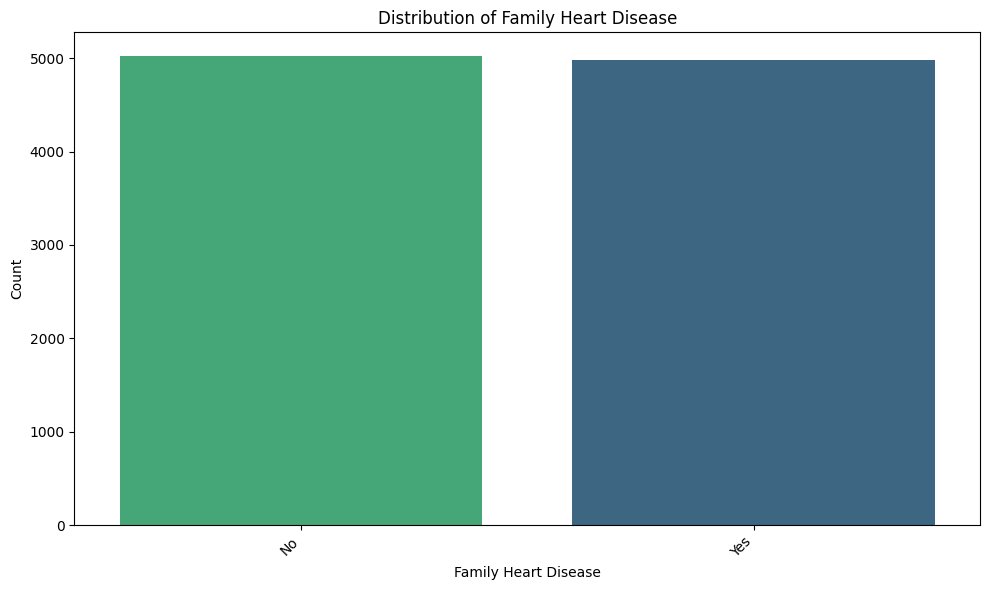

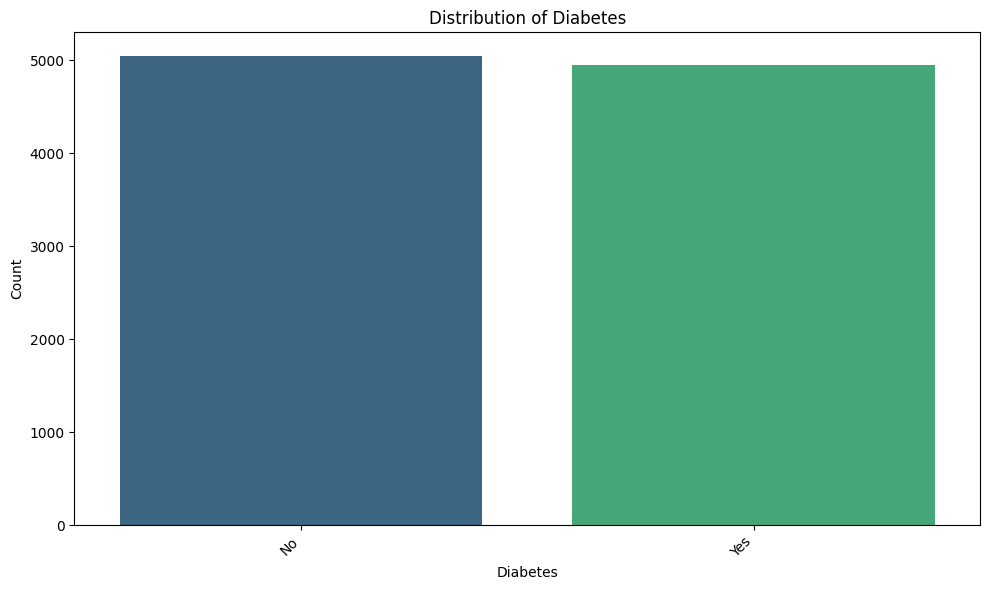

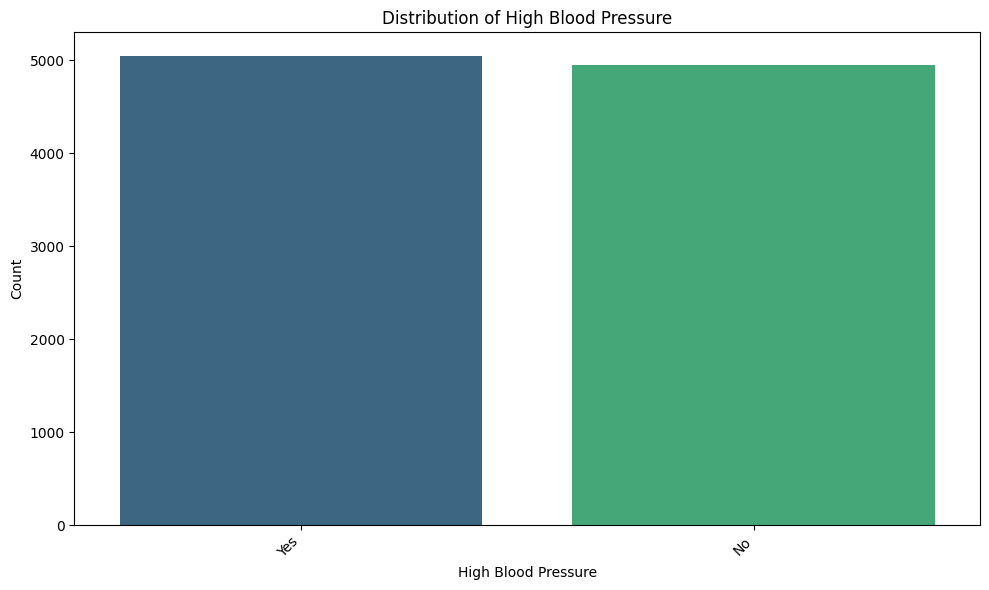

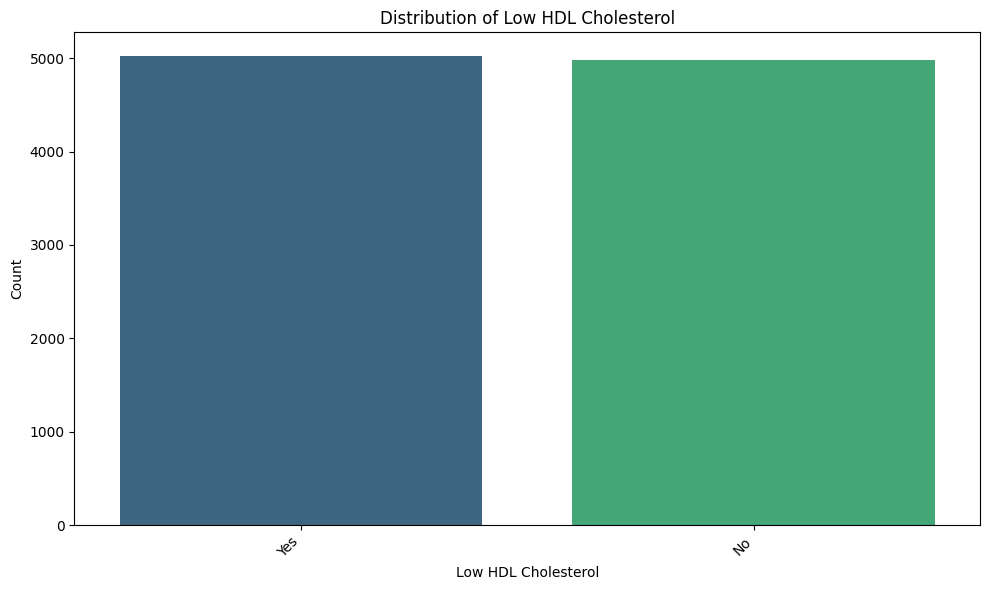

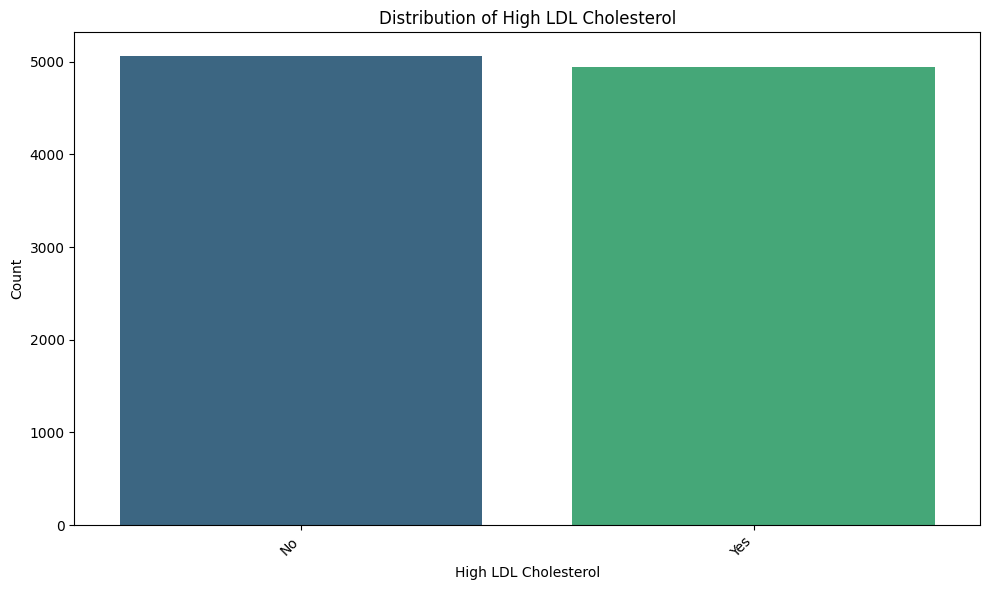

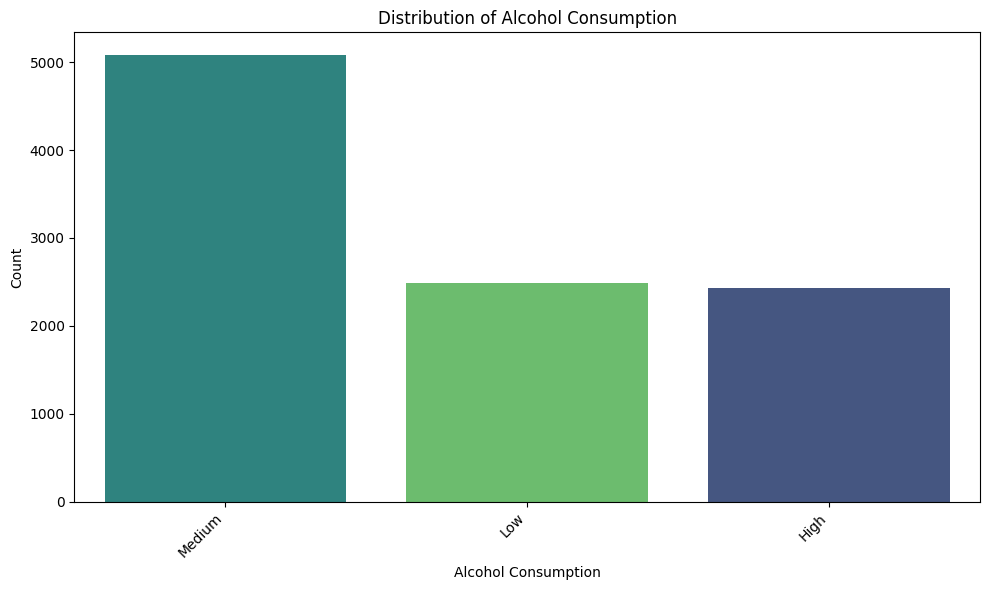

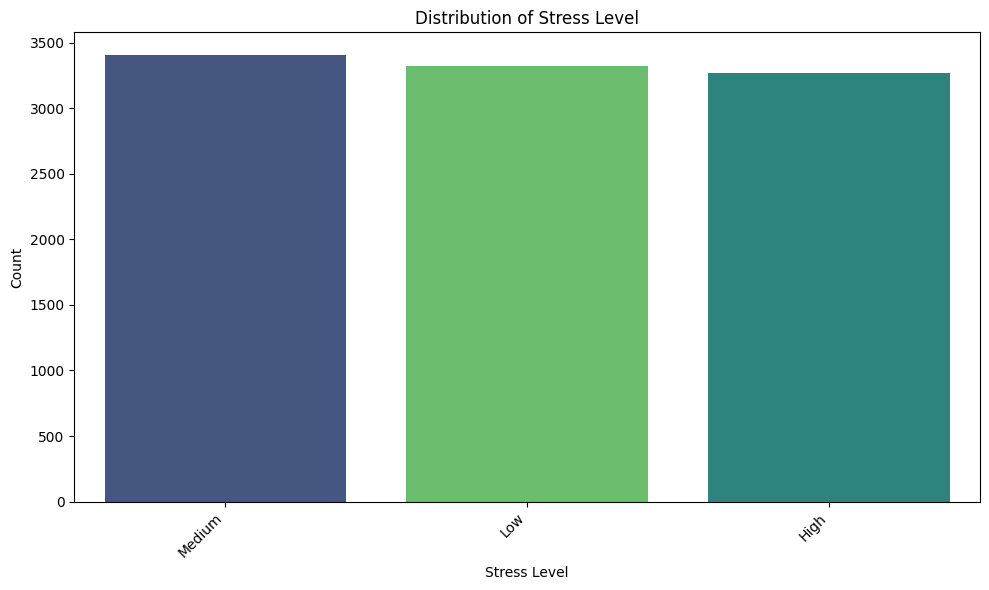

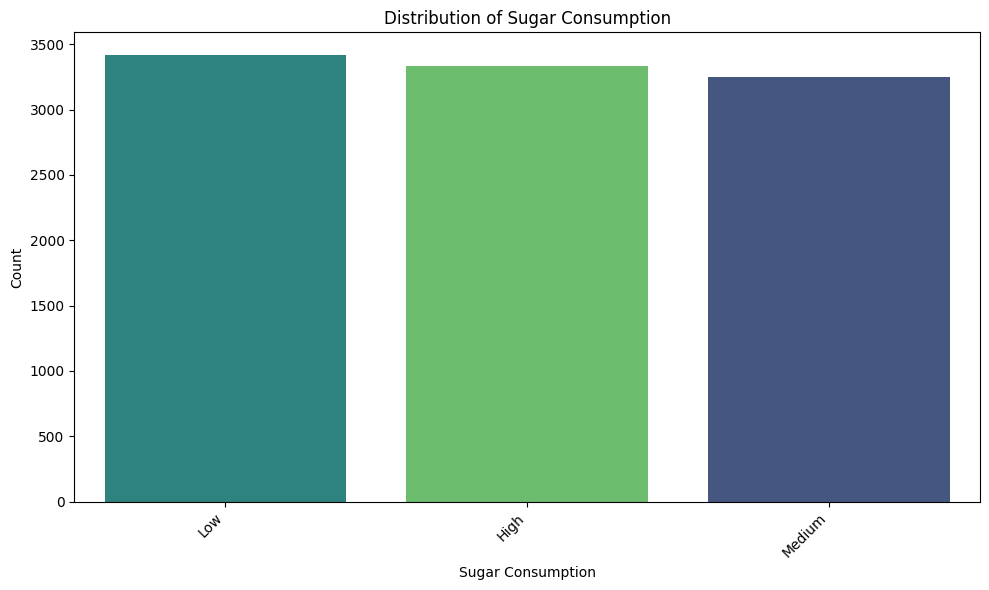

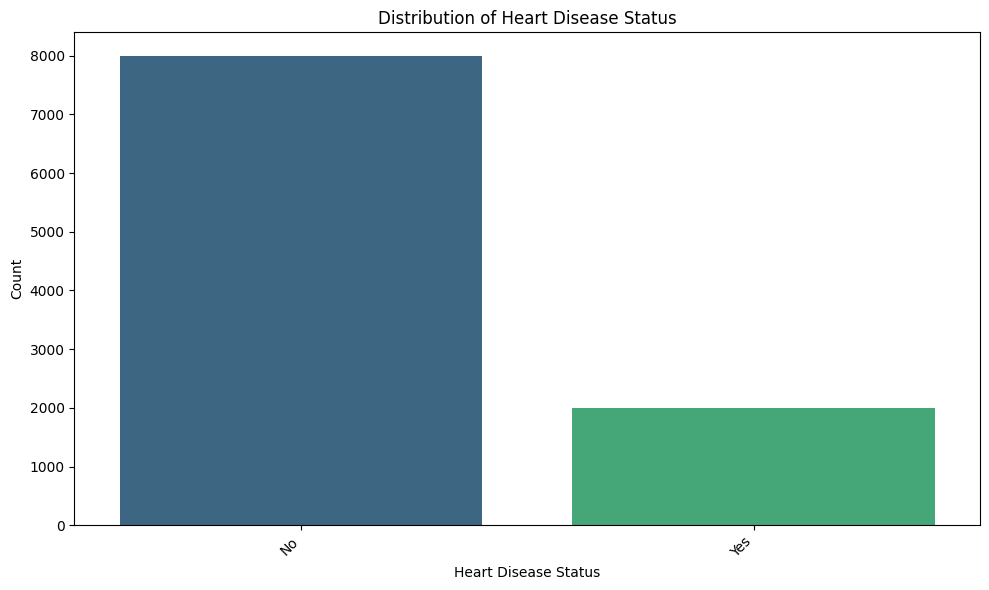

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue=col, palette='viridis', order=df[col].value_counts().index, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# **One-Hot Encoding for Categorical Variables and Target**

In [100]:
categorical_cols_to_encode = [
    'Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
    'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
    'Alcohol Consumption', 'Stress Level', 'Sugar Consumption'
]

df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

print("One-hot encoding complete. Displaying first 5 rows of the updated DataFrame:")
df_encoded.head()

One-hot encoding complete. Displaying first 5 rows of the updated DataFrame:


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,...,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium
0,56.0,153.0,155.0,24.991591,7.633228,342.0,120.0,12.969246,12.387250,No,...,False,True,True,False,False,False,False,True,False,True
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,No,...,True,False,True,False,False,True,False,False,False,True
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,No,...,False,False,True,True,True,False,True,False,True,False
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,No,...,False,True,False,True,True,False,False,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,No,...,True,True,False,False,True,False,False,False,False,False


In [101]:
df_encoded['Heart Disease Status'] = df_encoded['Heart Disease Status'].map({'Yes': 1, 'No': 0})

print("Value counts for 'Heart Disease Status' after encoding:")
print(df_encoded['Heart Disease Status'].value_counts())

Value counts for 'Heart Disease Status' after encoding:
Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


In [102]:
df_encoded.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,...,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium
0,56.0,153.0,155.0,24.991591,7.633228,342.0,120.0,12.969246,12.387250,0,...,False,True,True,False,False,False,False,True,False,True
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,0,...,True,False,True,False,False,True,False,False,False,True
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,0,...,False,False,True,True,True,False,True,False,True,False
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,0,...,False,True,False,True,True,False,False,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,0,...,True,True,False,False,True,False,False,False,False,False


# **Standardization of Numerical Features for Scaling**

In [103]:
from sklearn.preprocessing import StandardScaler

numerical_cols_to_scale = [
    'Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
    'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level'
]

scaler = StandardScaler()
df_encoded[numerical_cols_to_scale] = scaler.fit_transform(df_encoded[numerical_cols_to_scale])

"\nDescriptive statistics for scaled numerical columns:"
df_encoded[numerical_cols_to_scale].describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,-3.339551e-17,6.835421e-16,-5.497824e-17,3.069545e-16,1.726619e-16,1.437073e-16,-2.831513e-16,2.295053e-16,2.344791e-17
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-1.722683e+00,-1.695103e+00,-1.733633e+00,-1.757892e+00,-1.708109e+00,-1.733561e+00,-1.704042e+00,-1.723095e+00,-1.726358e+00
25%,-8.419487e-01,-8.976274e-01,-8.832192e-01,-8.584957e-01,-8.772964e-01,-8.594920e-01,-8.974832e-01,-8.744956e-01,-8.628168e-01
50%,-1.626055e-02,1.377355e-02,1.316303e-02,3.520363e-04,6.792496e-03,-8.424419e-03,-6.023719e-03,-8.330319e-06,-1.083191e-02
75%,8.644734e-01,8.682120e-01,8.635769e-01,8.622019e-01,8.775863e-01,8.656450e-01,8.854358e-01,8.704071e-01,8.508658e-01
max,1.690162e+00,1.722650e+00,1.713991e+00,1.733326e+00,1.718298e+00,1.716713e+00,1.691994e+00,1.736091e+00,1.746483e+00


In [104]:
print("First 5 rows after scaling numerical features:")
df_encoded.head()

First 5 rows after scaling numerical features:


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,...,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium
0,0.369061,0.184661,-1.618712,-0.648537,0.366591,1.049660,-0.006024,1.268241,-0.015959,0,...,False,True,True,False,False,False,False,True,False,True
1,1.084657,-0.214077,1.392213,-0.611996,1.001005,-1.354031,1.564643,0.434477,1.584367,0,...,True,False,True,False,False,True,False,False,False,True
2,-0.181398,-1.353328,-0.216679,0.123523,-1.456907,1.636206,-1.194636,1.208400,-0.283696,0,...,False,False,True,True,True,False,True,False,True,False
3,-0.952040,-1.581178,1.553102,-0.785226,-0.994883,0.486115,-1.109735,1.162067,-1.503680,0,...,False,True,False,True,True,False,False,False,False,False
4,0.589244,0.925175,0.380910,-1.363683,0.022624,0.141087,1.437292,0.671158,-0.996158,0,...,True,True,False,False,True,False,False,False,False,False


In [105]:
X = df_encoded.drop('Heart Disease Status', axis=1)
y = df_encoded['Heart Disease Status']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (10000, 24)
Shape of target (y): (10000,)


# **Feature Selection Using SelectKBest for Top Features**

In [106]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

selector.fit(X, y)

selected_features_indices = selector.get_support(indices=True)

selected_features = X.columns[selected_features_indices]

selected_scores = selector.scores_[selected_features_indices]

print("Top 10 features and their F-scores:")
for feature, score in zip(selected_features, selected_scores):
    print(f"Feature: {feature}, F-score: {score:.2f}")

Top 10 features and their F-scores:
Feature: Age, F-score: 0.85
Feature: Blood Pressure, F-score: 1.93
Feature: BMI, F-score: 3.87
Feature: Homocysteine Level, F-score: 0.69
Feature: Gender_Male, F-score: 2.96
Feature: High LDL Cholesterol_Yes, F-score: 0.67
Feature: Alcohol Consumption_Medium, F-score: 2.93
Feature: Stress Level_Low, F-score: 4.97
Feature: Stress Level_Medium, F-score: 6.20
Feature: Sugar Consumption_Medium, F-score: 0.73


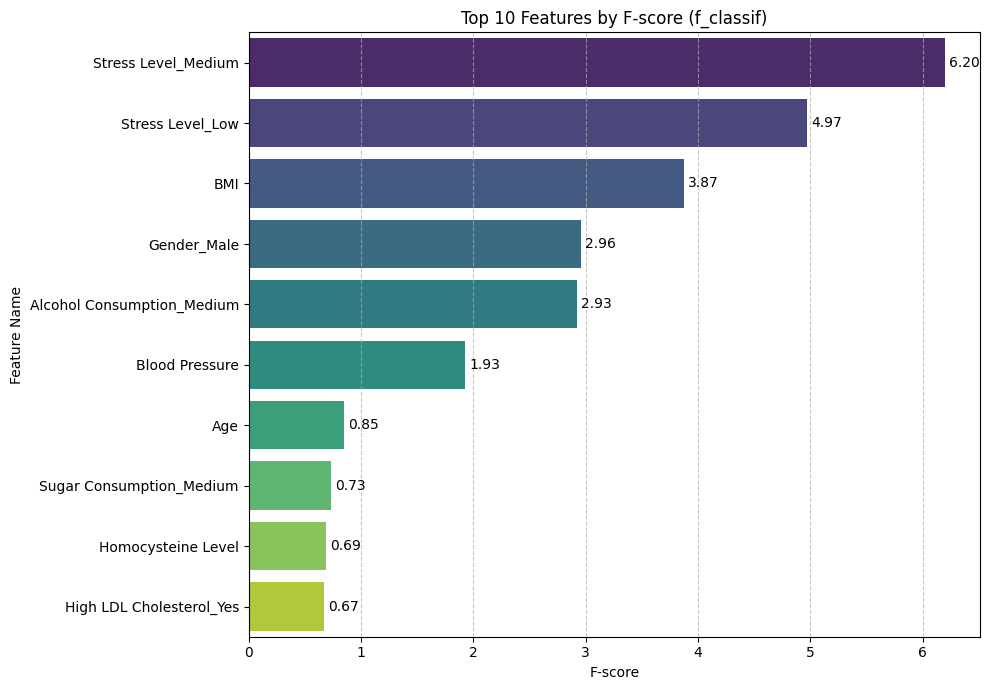

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_scores = pd.DataFrame({'Feature': selected_features, 'F-score': selected_scores})
feature_scores = feature_scores.sort_values(by='F-score', ascending=False)

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='F-score', y='Feature', data=feature_scores, hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Features by F-score (f_classif)')
plt.xlabel('F-score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f',  padding=3)

plt.tight_layout()
plt.show()

# **Splitting Data into Training and Testing Sets**

In [108]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Heart Disease Status', axis=1)
y = df_encoded['Heart Disease Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 24)
Shape of X_test: (2000, 24)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [110]:
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("\nData types of the columns after conversion:")
print(df_encoded.dtypes)


Data types of the columns after conversion:
Age                           float64
Blood Pressure                float64
Cholesterol Level             float64
BMI                           float64
Sleep Hours                   float64
Triglyceride Level            float64
Fasting Blood Sugar           float64
CRP Level                     float64
Homocysteine Level            float64
Heart Disease Status            int64
Gender_Male                     int64
Exercise Habits_Low             int64
Exercise Habits_Medium          int64
Smoking_Yes                     int64
Family Heart Disease_Yes        int64
Diabetes_Yes                    int64
High Blood Pressure_Yes         int64
Low HDL Cholesterol_Yes         int64
High LDL Cholesterol_Yes        int64
Alcohol Consumption_Low         int64
Alcohol Consumption_Medium      int64
Stress Level_Low                int64
Stress Level_Medium             int64
Sugar Consumption_Low           int64
Sugar Consumption_Medium        int64
dtype

# **Handling Class Imbalance with SMOTE Resampling**

In [111]:
print("Class distribution in the training set (y_train):")
class_counts = y_train.value_counts()
print(class_counts)

print("\nClass percentage distribution:")
class_percentages = y_train.value_counts(normalize=True) * 100
print(class_percentages)


Class distribution in the training set (y_train):
Heart Disease Status
0    6387
1    1613
Name: count, dtype: int64

Class percentage distribution:
Heart Disease Status
0    79.8375
1    20.1625
Name: proportion, dtype: float64


In [112]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

print("Applying SMOTE to balance the training data...")

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)

print("Class distribution after SMOTE (y_train_resampled):")
print(y_train_resampled.value_counts())

Applying SMOTE to balance the training data...
Shape of X_train_resampled: (12774, 24)
Shape of y_train_resampled: (12774,)
Class distribution after SMOTE (y_train_resampled):
Heart Disease Status
1    6387
0    6387
Name: count, dtype: int64


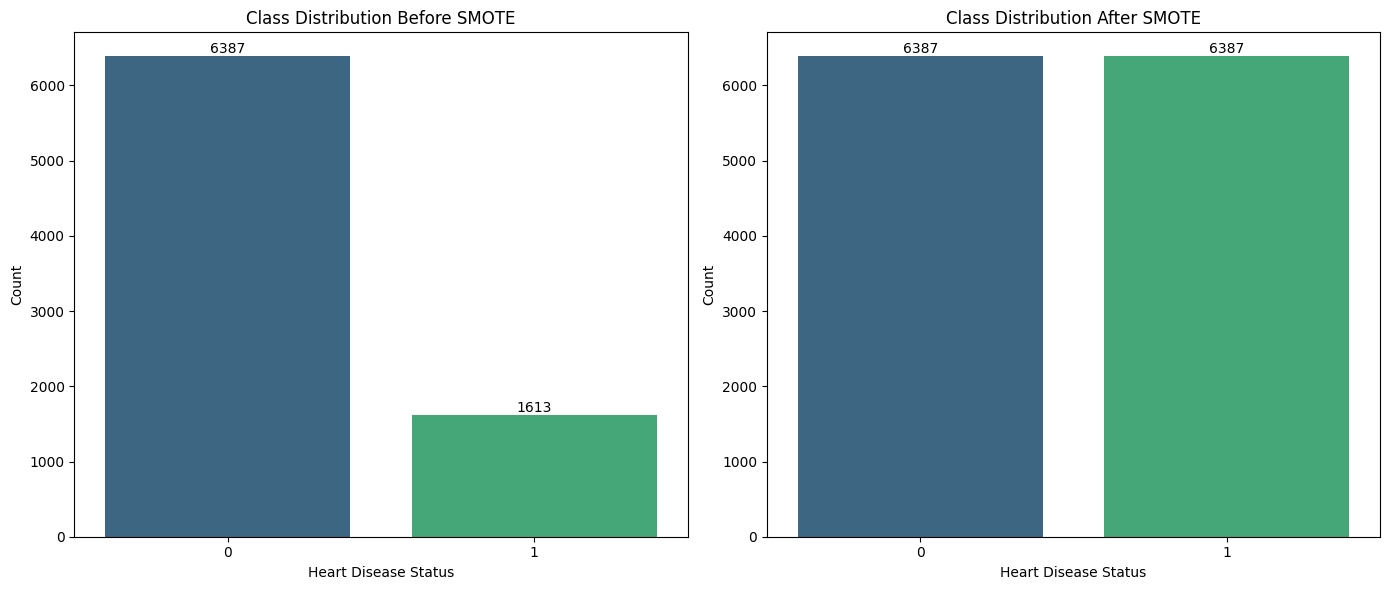

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x=y_train, ax=axes[0], hue=y_train, palette='viridis', legend=False)
axes[0].set_title('Class Distribution Before SMOTE')
axes[0].set_xlabel('Heart Disease Status')
axes[0].set_ylabel('Count')
axes[0].ticklabel_format(style='plain', axis='y')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

sns.countplot(x=y_train_resampled, ax=axes[1], hue=y_train_resampled, palette='viridis', legend=False)
axes[1].set_title('Class Distribution After SMOTE')
axes[1].set_xlabel('Heart Disease Status')
axes[1].set_ylabel('Count')
axes[1].ticklabel_format(style='plain', axis='y')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

# **Training and Evaluating Logistic Regression**

In [114]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

print("Training Logistic Regression model...")

log_reg_model.fit(X_train_resampled, y_train_resampled)

print("Logistic Regression model trained successfully.")

Training Logistic Regression model...
Logistic Regression model trained successfully.


In [115]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred_logreg = log_reg_model.predict(X_test)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg, pos_label=1, zero_division=0)
recall_logreg = recall_score(y_test, y_pred_logreg, pos_label=1, zero_division=0)
f1_logreg = f1_score(y_test, y_pred_logreg, pos_label=1, zero_division=0)
roc_auc_logreg = roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:, 1])
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)

logreg_results = {
    'Accuracy': accuracy_logreg,
    'Precision': precision_logreg,
    'Recall': recall_logreg,
    'F1 Score': f1_logreg,
    'ROC-AUC': roc_auc_logreg,
    'Confusion Matrix': conf_matrix_logreg
}

print("Logistic Regression Model Performance on Test Set:")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall: {recall_logreg:.4f}")
print(f"F1 Score: {f1_logreg:.4f}")
print(f"ROC-AUC Score: {roc_auc_logreg:.4f}")
print("Confusion Matrix:")
print(conf_matrix_logreg)

Logistic Regression Model Performance on Test Set:
Accuracy: 0.5895
Precision: 0.1790
Recall: 0.3127
F1 Score: 0.2277
ROC-AUC Score: 0.4815
Confusion Matrix:
[[1058  555]
 [ 266  121]]

Evaluation metrics stored in 'logreg_results' dictionary.


## **Training and Evaluating DecisionTree**

In [120]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

print("Training Decision Tree Classifier model...")

dt_model.fit(X_train_resampled, y_train_resampled)

print("Decision Tree Classifier model trained successfully.")

Training Decision Tree Classifier model...
Decision Tree Classifier model trained successfully.


In [122]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, pos_label=1, zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, pos_label=1, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, pos_label=1, zero_division=0)
roc_auc_dt = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

dt_results = {
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1 Score': f1_dt,
    'ROC-AUC': roc_auc_dt,
    'Confusion Matrix': conf_matrix_dt
}

print("Decision Tree Classifier Model Performance on Test Set:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1 Score: {f1_dt:.4f}")
print(f"ROC-AUC Score: {roc_auc_dt:.4f}")
print("Confusion Matrix:")
print(conf_matrix_dt)

Decision Tree Classifier Model Performance on Test Set:
Accuracy: 0.6230
Precision: 0.2045
Recall: 0.3282
F1 Score: 0.2520
ROC-AUC Score: 0.5110
Confusion Matrix:
[[1119  494]
 [ 260  127]]


# **Training and Evaluating RandomForest**

In [123]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

print("Training Random Forest Classifier model...")
rf_model.fit(X_train_resampled, y_train_resampled)

print("Random Forest Classifier model trained successfully.")

Training Random Forest Classifier model...
Random Forest Classifier model trained successfully.


In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

rf_results = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1 Score': f1_rf,
    'ROC-AUC': roc_auc_rf,
    'Confusion Matrix': conf_matrix_rf
}

print("Random Forest Classifier Model Performance on Test Set:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")
print("Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Classifier Model Performance on Test Set:
Accuracy: 0.7430
Precision: 0.1809
Recall: 0.0930
F1 Score: 0.1229
ROC-AUC Score: 0.5018
Confusion Matrix:
[[1450  163]
 [ 351   36]]


# **Confusion Matrix - Logistic Regression Model**

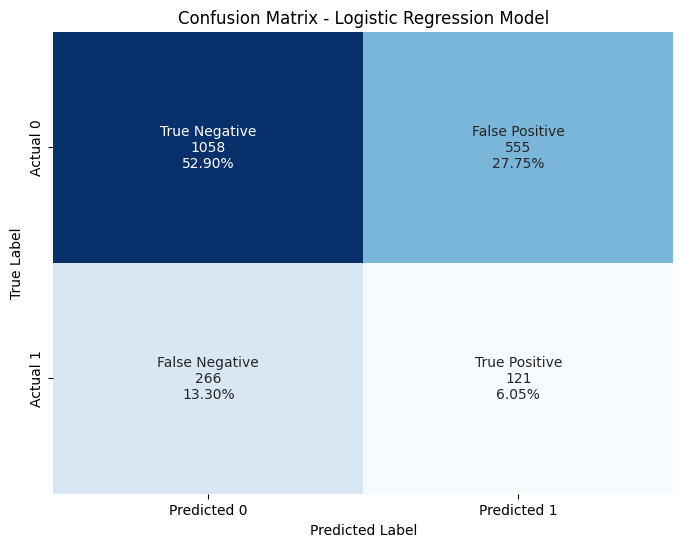

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix_logreg = logreg_results['Confusion Matrix']

group_names = ['True Negative','False Positive','False Negative','True Positive']
group_counts = ['{0:0.0f}'.format(value) for value in conf_matrix_logreg.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in conf_matrix_logreg.flatten()/np.sum(conf_matrix_logreg)]

labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix_logreg, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.title('Confusion Matrix - Logistic Regression Model')

plt.show()

# **Confusion Matrix - Decision Tree Classifier Model**

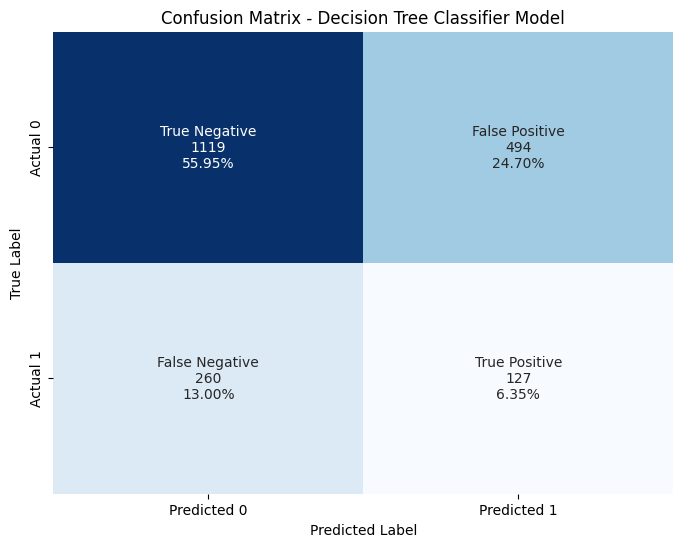

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf_matrix_dt = dt_results['Confusion Matrix']

group_names = ['True Negative','False Positive','False Negative','True Positive']
group_counts = ['{0:0.0f}'.format(value) for value in conf_matrix_dt.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in conf_matrix_dt.flatten()/np.sum(conf_matrix_dt)]

labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix_dt, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.title('Confusion Matrix - Decision Tree Classifier Model')

plt.show()

# **Confusion Matrix - Random Forest Classifier Model**

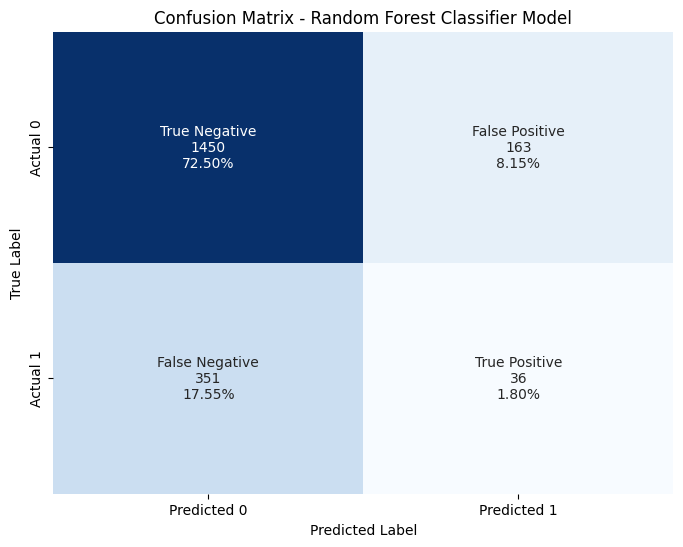

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf_matrix_rf = rf_results['Confusion Matrix']

group_names = ['True Negative','False Positive','False Negative','True Positive']
group_counts = ['{0:0.0f}'.format(value) for value in conf_matrix_rf.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in conf_matrix_rf.flatten()/np.sum(conf_matrix_rf)]

labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix_rf, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.title('Confusion Matrix - Random Forest Classifier Model')

plt.show()

# **Comparison of Model Performance Metrics**

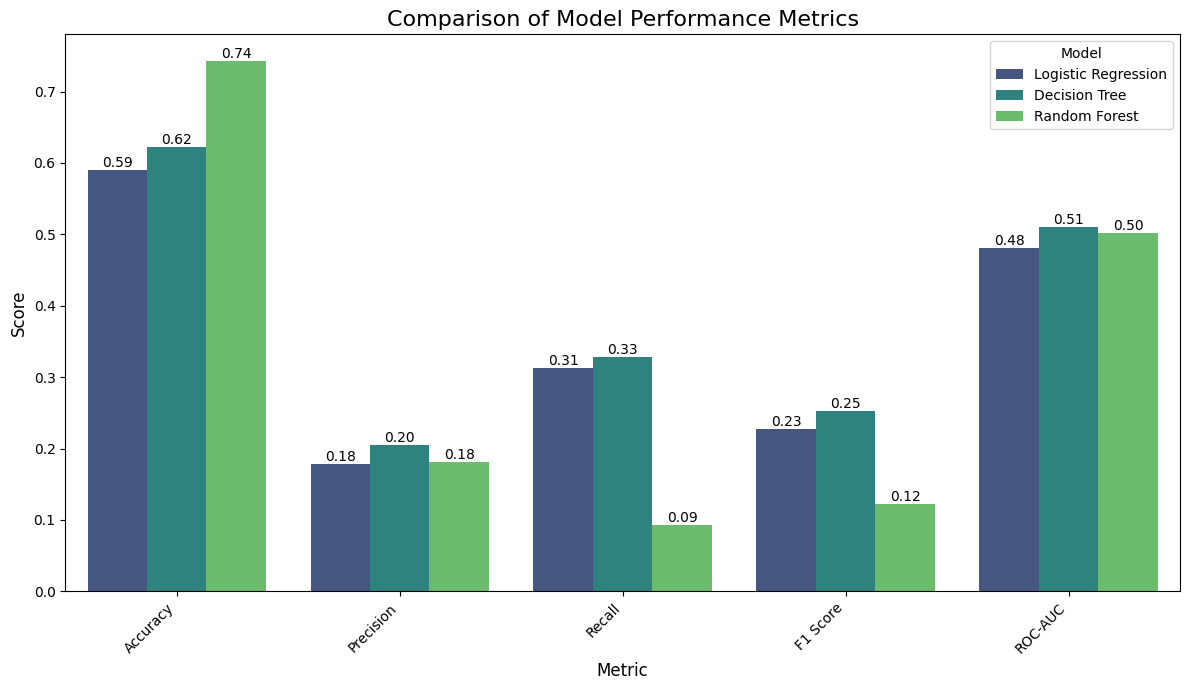

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

logreg_metrics = [logreg_results[m] for m in metrics]
dt_metrics = [dt_results[m] for m in metrics]
rf_metrics = [rf_results[m] for m in metrics]

performance_data = pd.DataFrame({
    'Metric': metrics,
    'Logistic Regression': logreg_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics
})

performance_melted = performance_data.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=performance_melted, palette='viridis')

plt.title('Comparison of Model Performance Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)

plt.xticks(rotation=45, ha='right')

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', label_type='edge')

plt.tight_layout()
plt.show()
